In [36]:
# import the libraries as shown below

from tensorflow.keras.layers import Input, Lambda, Dense, Flatten,Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

    


PyTorch: 2.13.0+cpu
Torchvision: 0.28.0+cpu
Matplotlib: 3.11.1
PyTorch: 2.13.0+cpu
CUDA available: False
Running on CPU


In [37]:
import sys

print(sys.executable)

import site
print(site.getsitepackages())

import torch
print(torch.__version__)

import time
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("CPU devices:", tf.config.list_physical_devices("CPU"))
print("GPU devices:", tf.config.list_physical_devices("GPU"))

start = time.time()

model = tf.keras.applications.VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("Model loading time:", round(time.time() - start, 2), "seconds")

print("Total parameters:", model.count_params())





C:\Users\user\anaconda3\envs\pytorch\python.exe
['C:\\Users\\user\\anaconda3\\envs\\pytorch', 'C:\\Users\\user\\anaconda3\\envs\\pytorch\\Lib\\site-packages']
2.13.0+cpu
TensorFlow: 2.21.0
CPU devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU devices: []
Model loading time: 2.47 seconds
Total parameters: 20024384


In [38]:
# re-size all the images to this
IMAGE_SIZE = [224, 224]

train_path = 'Dataset/Train'
valid_path = 'Dataset/Test'


In [39]:
# Import the Vgg 16 library as shown below and add preprocessing layer to the front of VGG
# Here we will be using imagenet weights

vgg19 = VGG19(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)




In [40]:
# don't train existing weights
for layer in vgg19.layers:
    layer.trainable = False

In [41]:
  # useful for getting number of output classes
folders = glob('D:/ML Projects/Brain Tumor Project/Dataset/Train/*')

In [42]:
folders

['D:/ML Projects/Brain Tumor Project/Dataset/Train\\Brain Tumor',
 'D:/ML Projects/Brain Tumor Project/Dataset/Train\\Normal']

In [43]:
# our layers - you can add more if you want
x = Flatten()(vgg19.output)

In [44]:
prediction = Dense(len(folders), activation='softmax')(x)

# create a model object
model = Model(inputs=vgg19.input, outputs=prediction)

In [45]:

# view the structure of the model
model.summary()


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 20,074,562 (76.58 MB)

 Trainable params: 50,178 (196.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [46]:
from tensorflow.keras.layers import MaxPooling2D

In [47]:
### Create Model from scratch using CNN
model=Sequential()
model.add(Conv2D(filters=16,kernel_size=2,padding="same",activation="relu",input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=32,kernel_size=2,padding="same",activation ="relu"))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=64,kernel_size=2,padding="same",activation="relu"))
model.add(MaxPooling2D(pool_size=2))
model.add(Flatten())
model.add(Dense(500,activation="relu"))
model.add(Dense(2,activation="softmax"))
model.summary()

C:\Users\user\anaconda3\envs\pytorch\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 224, 224, 16)        │             208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 112, 112, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 112, 112, 32)        │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 56, 56, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 64)          │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 500)                 │      25,088,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │           1,002 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,100,046 (95.75 MB)

 Trainable params: 25,100,046 (95.75 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# tell the model what cost and optimization method to use
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)


In [49]:
# Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [50]:
# Make sure you provide the same target size as initialied for the image size
training_set = train_datagen.flow_from_directory('D:/ML Projects/Brain Tumor Project/Dataset/Train/',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 200 images belonging to 2 classes.


In [51]:
training_set

In [52]:
test_set = test_datagen.flow_from_directory('D:/ML Projects/Brain Tumor Project/Dataset/Test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 53 images belonging to 2 classes.


In [53]:
# fit the model
# Run the cell. It will take some time to execute
r = model.fit(
  training_set,
  validation_data=test_set,
  epochs=10,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6200 - loss: 4.4644 - val_accuracy: 0.5472 - val_loss: 1.2300
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7150 - loss: 0.8088 - val_accuracy: 0.6226 - val_loss: 0.6719
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6300 - loss: 0.6815 - val_accuracy: 0.6415 - val_loss: 0.6554
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7150 - loss: 0.5649 - val_accuracy: 0.5094 - val_loss: 0.6564
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6800 - loss: 0.5628 - val_accuracy: 0.6604 - val_loss: 0.6119
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7500 - loss: 0.5248 - val_accuracy: 0.8302 - val_loss: 0.5533
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7850 - loss: 0.5038 - val_accuracy: 0.8302 - val_loss: 0.5017
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7300 - loss: 0.5227 - val_accuracy: 0.8491 - val_loss: 0.5002
Epoch 9/10
7

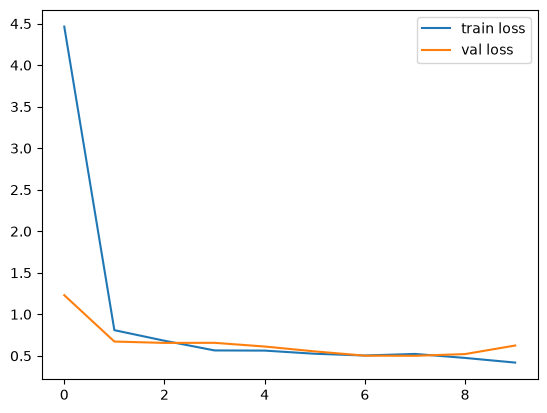

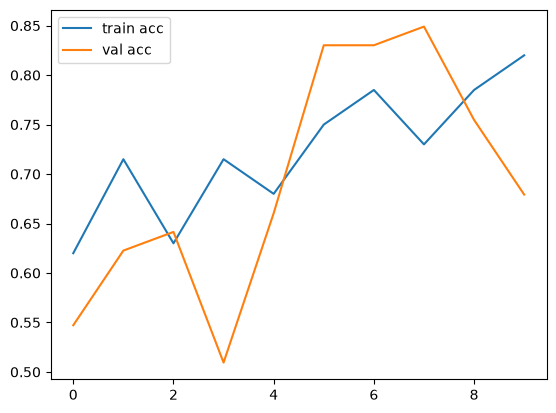

<Figure size 640x480 with 0 Axes>

In [54]:
# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [55]:
# save it as a h5 file


from tensorflow.keras.models import load_model

model.save('model_vgg19.h5')

In [56]:
y_pred = model.predict(test_set)


1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/stepWARNING:tensorflow:5 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000021340042E80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 315ms/step


In [57]:
y_pred

array([[0.88376963, 0.11623038],
       [0.8642407 , 0.13575931],
       [0.8462435 , 0.15375651],
       [0.5443502 , 0.4556497 ],
       [0.82207704, 0.17792293],
       [0.8776304 , 0.12236959],
       [0.90897167, 0.0910283 ],
       [0.87624115, 0.12375884],
       [0.580608  , 0.41939202],
       [0.55039674, 0.4496032 ],
       [0.6426388 , 0.35736117],
       [0.63025224, 0.36974773],
       [0.1859149 , 0.8140851 ],
       [0.22816896, 0.771831  ],
       [0.31668922, 0.68331075],
       [0.86693853, 0.13306151],
       [0.96528494, 0.03471507],
       [0.33441702, 0.665583  ],
       [0.55039674, 0.4496032 ],
       [0.68099314, 0.31900695],
       [0.8596566 , 0.14034338],
       [0.78751814, 0.21248181],
       [0.91388005, 0.08611993],
       [0.688764  , 0.31123605],
       [0.77699125, 0.22300878],
       [0.47050968, 0.5294903 ],
       [0.43124267, 0.56875736],
       [0.7990646 , 0.20093541],
       [0.8832795 , 0.11672045],
       [0.97970736, 0.0202927 ],
       [0.

In [58]:
import numpy as np
y_pred = np.argmax(y_pred, axis=1)

In [59]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0])

In [60]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [61]:
model=load_model('model_vgg19.h5')

In [62]:
img=image.load_img('D:/ML Projects/Brain Tumor Project/Dataset/Test/Brain Tumor/Y188.JPG',target_size=(224,224))

In [63]:
img=image.load_img('D:/ML Projects/Brain Tumor Project/Dataset/Test/Normal/no 89.jpg',target_size=(224,224))

In [ ]:
x=image.img_to_array(img)
x

In [ ]:
x.shape

In [ ]:
x=x/255

In [ ]:
x=np.expand_dims(x,axis=0)
img_data=preprocess_input(x)
img_data.shape

In [ ]:
model.predict(img_data)

In [ ]:
a=np.argmax(model.predict(img_data), axis=1)

In [ ]:
if(a==1):
    print("Normal")
else:
    print("Brain Tumor")

In [1]:
import os
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_DIR = r"C:\Users\user\Documents\ML Projects\Brain Tumor Project"

TEST_PATH = os.path.join(
    PROJECT_DIR,
    "Dataset",
    "Test"
)

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "models",
    "brain_tumor_resnet50.pth"
)

print("Project:", PROJECT_DIR)
print("Test dataset:", TEST_PATH)
print("Saved model:", MODEL_PATH)

print("\nTest dataset exists:", os.path.exists(TEST_PATH))
print("Saved model exists:", os.path.exists(MODEL_PATH))

Project: C:\Users\user\Documents\ML Projects\Brain Tumor Project
Test dataset: C:\Users\user\Documents\ML Projects\Brain Tumor Project\Dataset\Test
Saved model: C:\Users\user\Documents\ML Projects\Brain Tumor Project\models\brain_tumor_resnet50.pth

Test dataset exists: True
Saved model exists: True


In [2]:
import torch
from torchvision import models

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# ============================================================
# RECREATE RESNET50 ARCHITECTURE
# ============================================================

model = models.resnet50(weights=None)

# Your project has 2 classes:
# 0 = Brain Tumor
# 1 = Normal

model.fc = torch.nn.Linear(
    model.fc.in_features,
    2
)

# ============================================================
# LOAD SAVED MODEL
# ============================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("Model loaded successfully!")
print("Model ready for test evaluation.")

Device: cpu
Model loaded successfully!
Model ready for test evaluation.


In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ============================================================
# TEST TRANSFORM
# ============================================================

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# TEST DATASET
# ============================================================

test_dataset = datasets.ImageFolder(
    TEST_PATH,
    transform=test_transform
)

# ============================================================
# TEST DATALOADER
# ============================================================

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

# ============================================================
# SAFETY / VERIFICATION
# ============================================================

print("Test images:", len(test_dataset))
print("Classes:", test_dataset.classes)
print("Class mapping:", test_dataset.class_to_idx)
print("Test batches:", len(test_loader))

Test images: 53
Classes: ['Brain Tumor', 'Normal']
Class mapping: {'Brain Tumor': 0, 'Normal': 1}
Test batches: 7


In [4]:
# ============================================================
# TEST-SET PREDICTIONS
# ============================================================

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Model prediction
        outputs = model(images)

        # Get predicted class
        _, predictions = torch.max(outputs, 1)

        # Store results
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# ============================================================
# VERIFY RESULTS
# ============================================================

print("Evaluation completed!")
print("Total test images evaluated:", len(all_labels))
print("Total predictions:", len(all_predictions))

print("\nFirst 10 actual labels:")
print(all_labels[:10])

print("\nFirst 10 predictions:")
print(all_predictions[:10])

Evaluation completed!
Total test images evaluated: 53
Total predictions: 53

First 10 actual labels:
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]

First 10 predictions:
[np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0)]


In [5]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# CALCULATE ACCURACY
# ============================================================

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print("=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)

print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Brain Tumor", "Normal"],
        digits=4
    )
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\nConfusion Matrix:")
print(cm)

TEST SET EVALUATION

Test Accuracy: 81.13%

Classification Report:

              precision    recall  f1-score   support

 Brain Tumor     0.8696    0.7407    0.8000        27
      Normal     0.7667    0.8846    0.8214        26

    accuracy                         0.8113        53
   macro avg     0.8181    0.8127    0.8107        53
weighted avg     0.8191    0.8113    0.8105        53


Confusion Matrix:
[[20  7]
 [ 3 23]]


In [6]:
import os
import json

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

os.makedirs(RESULTS_DIR, exist_ok=True)

evaluation_results = {
    "model": "ResNet50",
    "task": "Brain Tumor vs Normal MRI Classification",
    "test_images": 53,
    "test_accuracy": 0.8113,
    "brain_tumor": {
        "precision": 0.8696,
        "recall": 0.7407,
        "f1_score": 0.8000,
        "support": 27
    },
    "normal": {
        "precision": 0.7667,
        "recall": 0.8846,
        "f1_score": 0.8214,
        "support": 26
    },
    "confusion_matrix": [
        [20, 7],
        [3, 23]
    ]
}

RESULTS_FILE = os.path.join(
    RESULTS_DIR,
    "test_evaluation.json"
)

with open(RESULTS_FILE, "w") as f:
    json.dump(evaluation_results, f, indent=4)

print("Evaluation results saved successfully!")
print("File:", RESULTS_FILE)

Evaluation results saved successfully!
File: C:\Users\user\Documents\ML Projects\Brain Tumor Project\results\test_evaluation.json
